# Exp3 figure release audit

This notebook audits release-level figure interfaces from existing `outputs/full` artifacts only.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display

def locate_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'plot_results.py').exists() and (candidate / 'outputs' / 'full').exists():
            return candidate
    raise RuntimeError('Could not locate project root with plot_results.py and outputs/full')

PROJECT_ROOT = locate_root(Path.cwd().resolve())
FULL = PROJECT_ROOT / 'outputs' / 'full'
CHECKS = FULL / 'checks'
CHECKS.mkdir(parents=True, exist_ok=True)
PROJECT_ROOT, FULL

(WindowsPath('D:/research/CausalRegretMinimizationUnderDelayedFeedback/experiment/github/exp3_sequential_recommendation_delayed_feedback'),
 WindowsPath('D:/research/CausalRegretMinimizationUnderDelayedFeedback/experiment/github/exp3_sequential_recommendation_delayed_feedback/outputs/full'))

In [2]:
manifest = json.loads((FULL / 'metadata' / 'run_manifest.json').read_text(encoding='utf-8'))
assert manifest.get('run_mode') == 'full'
assert manifest.get('input_data_status') == 'real_kuairand_1k'
assert manifest.get('paper_result') is True
assert manifest.get('status') == 'complete'
manifest_subset = {k: manifest.get(k) for k in ['run_id', 'run_mode', 'input_data_status', 'paper_result', 'status']}
manifest_subset

{'run_id': 'full_20260624T081725Z_ff80ce71f7',
 'run_mode': 'full',
 'input_data_status': 'real_kuairand_1k',
 'paper_result': True,
 'status': 'complete'}

In [3]:
main_data = pd.read_csv(FULL / 'figures' / 'data' / 'fig_exp3_long_term_recoverability_data.csv')
main_meta = json.loads((FULL / 'figures' / 'metadata' / 'fig_exp3_long_term_recoverability_metadata.json').read_text(encoding='utf-8'))
horizon_data = pd.read_csv(FULL / 'figures' / 'data' / 'fig_app_exp3_horizon_eligibility_data.csv')
horizon_meta = json.loads((FULL / 'figures' / 'metadata' / 'fig_app_exp3_horizon_eligibility_metadata.json').read_text(encoding='utf-8'))
paired = pd.read_csv(FULL / 'summaries' / 'paired_effect_vs_history_mean_static.csv')
proxy_static = pd.read_csv(FULL / 'tables' / 'tbl_app_exp3_proxy_static_control.csv')
{'main_rows': len(main_data), 'horizon_rows': len(horizon_data), 'paired_rows': len(paired), 'proxy_static_rows': len(proxy_static)}

{'main_rows': 17, 'horizon_rows': 4, 'paired_rows': 18, 'proxy_static_rows': 4}

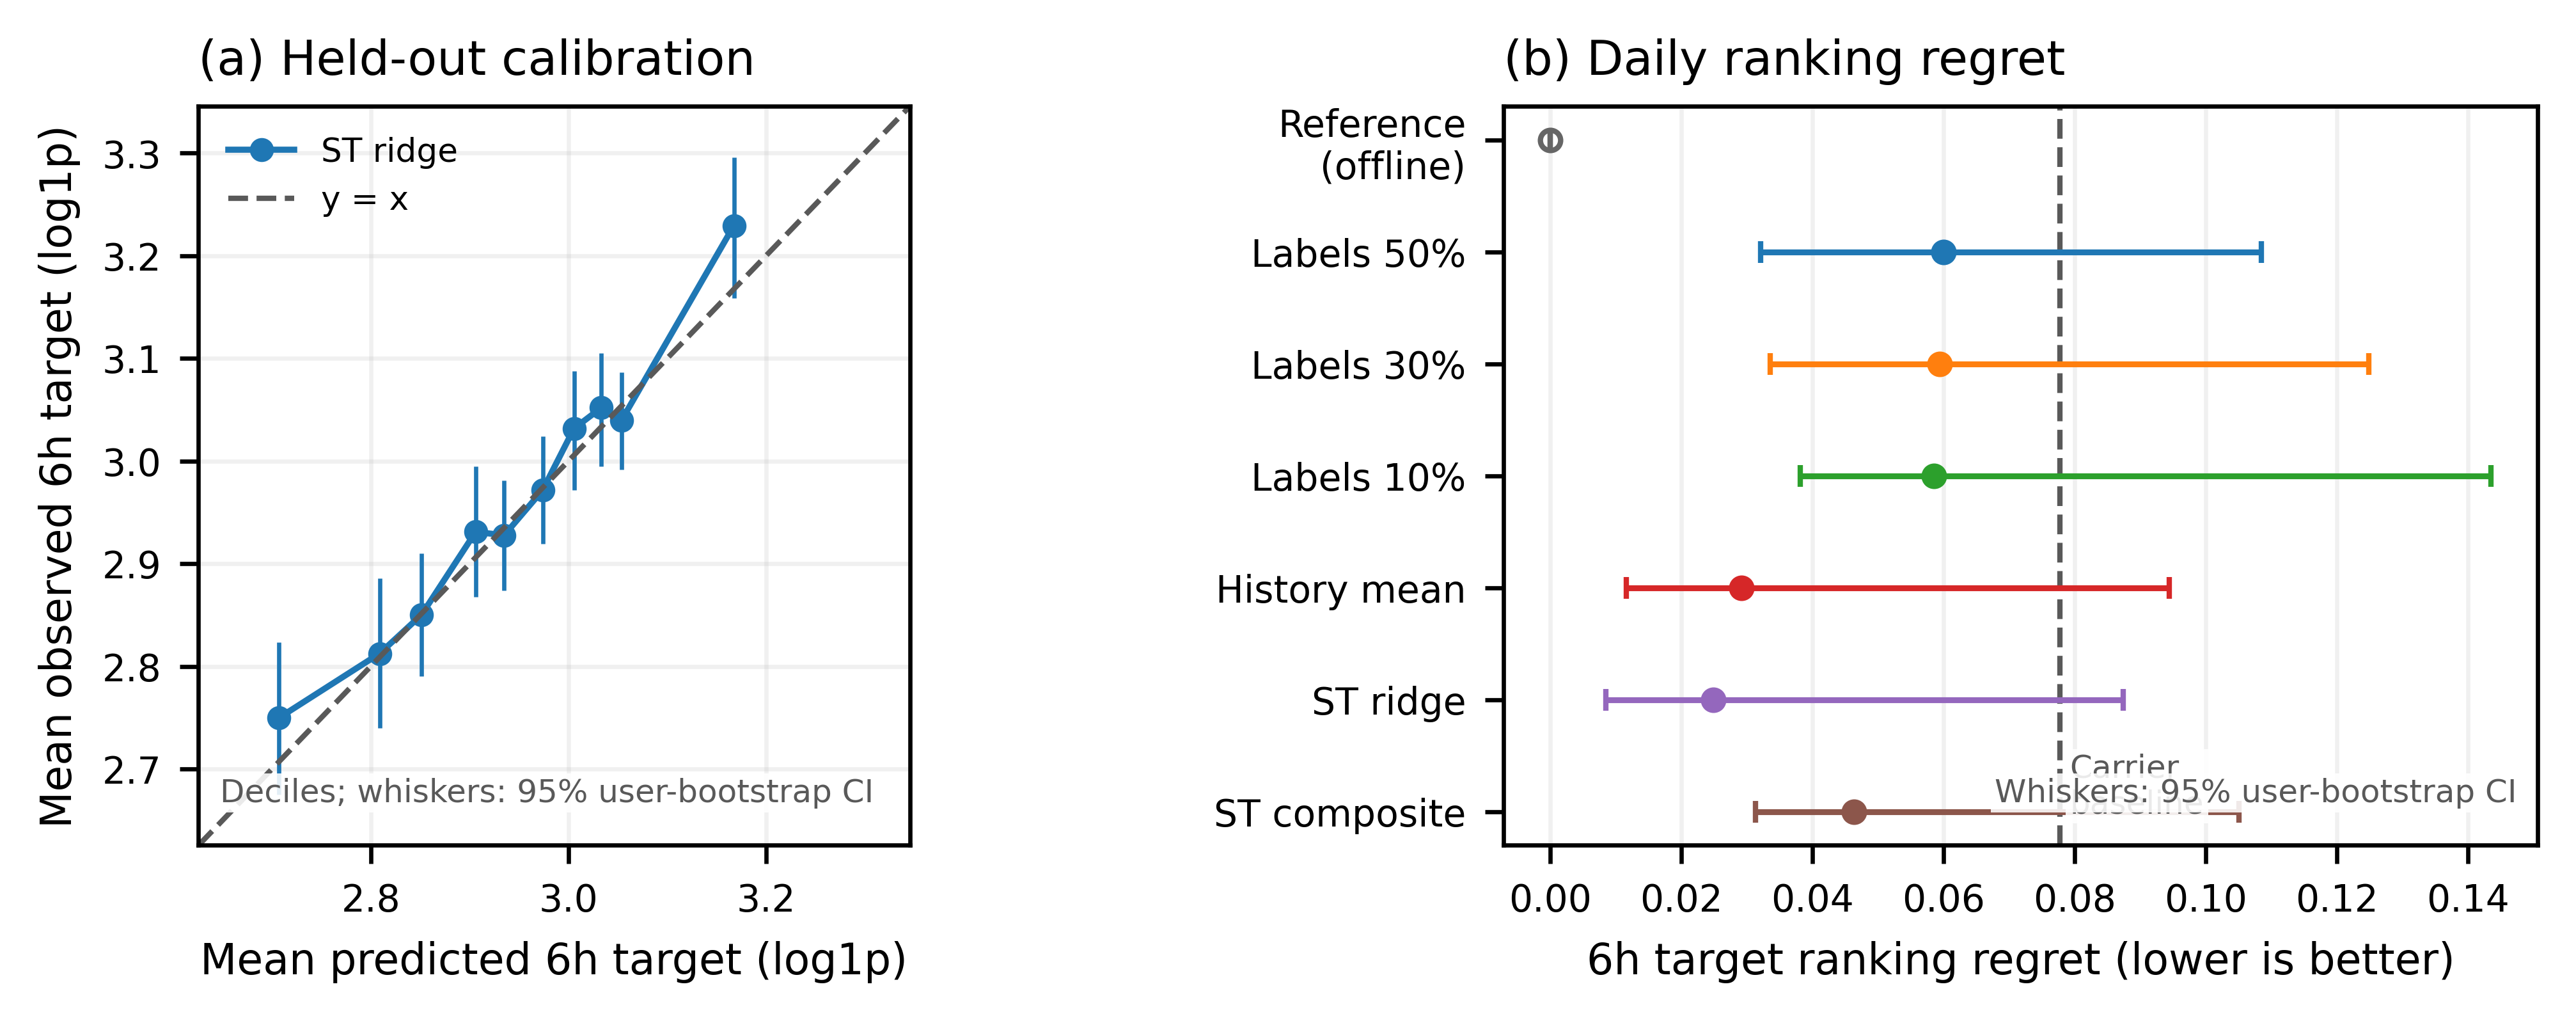

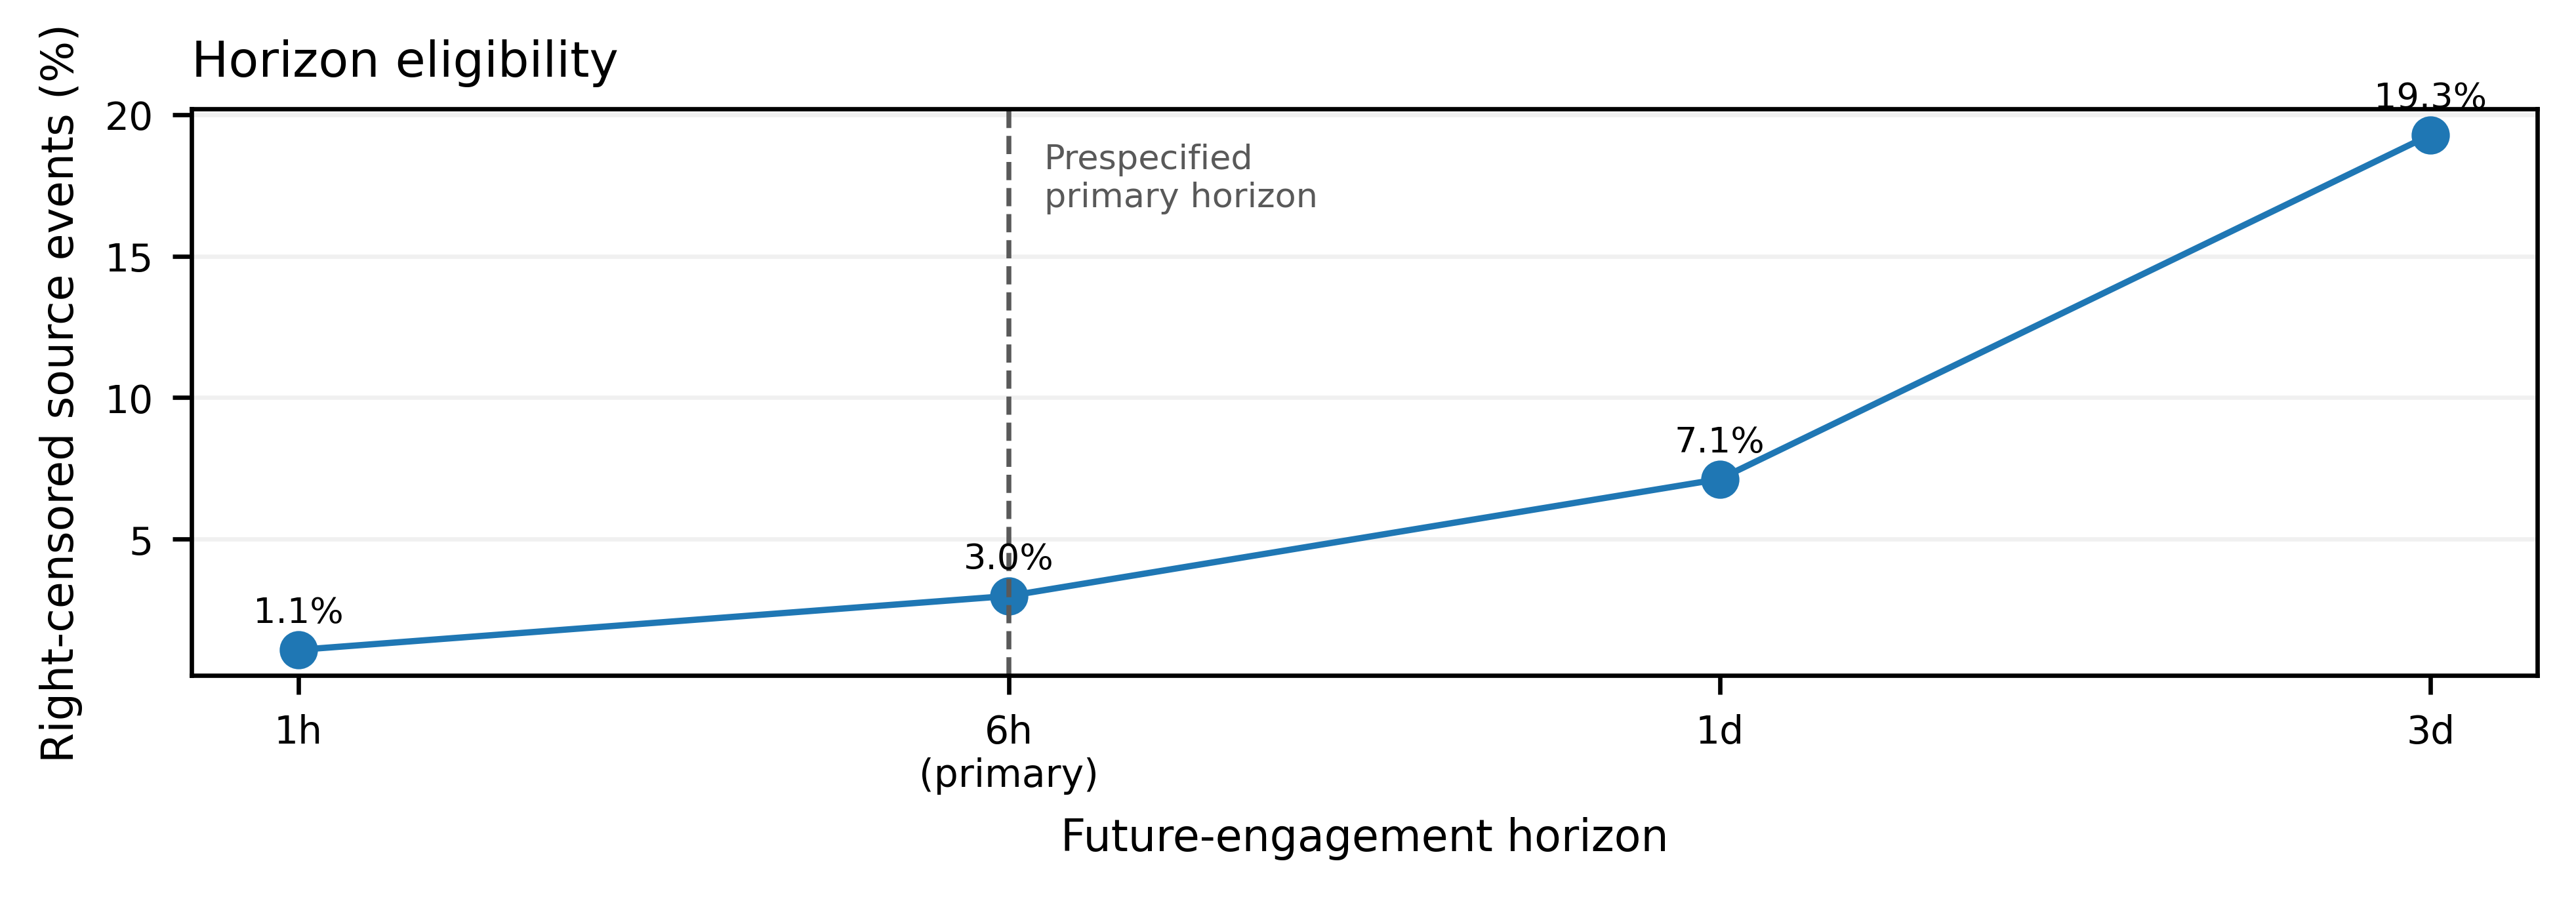

In [4]:
display(Image(filename=str(FULL / 'figures' / 'png' / 'fig_exp3_long_term_recoverability.png')))
display(Image(filename=str(FULL / 'figures' / 'png' / 'fig_app_exp3_horizon_eligibility.png')))

In [5]:
expected_panel_b = [
    'source_aware_reference',
    'partial_source_label_q50',
    'partial_source_label_q30',
    'partial_source_label_q10',
    'history_mean_static',
    'short_term_ridge_proxy',
    'short_term_composite_surrogate',
]
errors = []
panel_a = main_data[main_data['panel_id'].eq('panel_a')]
panel_b = main_data[main_data['panel_id'].eq('panel_b')]
panel_b_methods = panel_b['x_value'].astype(str).tolist()
if panel_b_methods != expected_panel_b:
    errors.append(f'Panel B method order mismatch: {panel_b_methods}')
panel_a_methods = panel_a['method_id'].dropna().astype(str).unique().tolist()
if panel_a_methods != ['short_term_ridge_proxy']:
    errors.append(f'Panel A methods mismatch: {panel_a_methods}')
history_rows = panel_b[panel_b['x_value'].astype(str).eq('history_mean_static')]
if len(history_rows) != 1 or history_rows['plot_label'].iloc[0] != 'History mean':
    errors.append('history_mean_static must appear exactly once with plot_label == History mean')
reference_rows = panel_b[panel_b['x_value'].astype(str).eq('source_aware_reference')]
if len(reference_rows) != 1 or str(reference_rows['deployable'].iloc[0]).lower() != 'false':
    errors.append('source_aware_reference must be deployable == false')

main_contract = main_meta.get('visual_contract', {})
horizon_contract = horizon_meta.get('visual_contract', {})
required_main_contract = {
    'panel_a_route_label': 'ST ridge',
    'panel_a_reference_label': 'y = x',
    'panel_a_uncertainty_label': 'Deciles; whiskers: 95% user-bootstrap CI',
    'panel_b_reference_label': 'Reference (offline)',
    'panel_b_carrier_label': 'Carrier baseline',
    'panel_b_uncertainty_label': 'Whiskers: 95% user-bootstrap CI',
    'panel_b_method_order': expected_panel_b,
}
for key, expected in required_main_contract.items():
    if main_contract.get(key) != expected:
        errors.append(f'main visual_contract mismatch for {key}')
if horizon_contract.get('primary_horizon_tick_label') != '6h (primary)':
    errors.append('horizon primary_horizon_tick_label mismatch')
if horizon_contract.get('primary_horizon_annotation') != 'Prespecified primary horizon':
    errors.append('horizon primary_horizon_annotation mismatch')
if horizon_contract.get('series_legend_removed') is not True:
    errors.append('horizon series_legend_removed must be true')
if errors:
    raise AssertionError('\n'.join(errors))
'figure visual contracts passed'

'figure visual contracts passed'

In [6]:
effect = paired[(paired['method_id'].eq('short_term_ridge_proxy')) & (paired['comparator_method_id'].eq('history_mean_static'))].iloc[0]
effect_text = (
    f"ST ridge versus History mean paired estimate: {effect['point_estimate']:.4f} "
    f"[{effect['ci_lower']:.4f}, {effect['ci_upper']:.4f}]"
)
display(Markdown('## Paired contrast\n\n' + effect_text))
effect_text

## Paired contrast

ST ridge versus History mean paired estimate: 0.0043 [-0.0050, 0.0147]

'ST ridge versus History mean paired estimate: 0.0043 [-0.0050, 0.0147]'

In [7]:
manual_checklist = [
    'no clipped tick labels',
    'no legend overlaps',
    'Carrier baseline visible',
    'Reference marked offline',
    'all CI explanations visible',
    'horizon figure does not use the word saturation',
]
audit_rows = [
    {'check_id': 'manifest_contract', 'status': 'passed', 'details': json.dumps(manifest_subset)},
    {'check_id': 'main_panel_b_methods', 'status': 'passed', 'details': ','.join(expected_panel_b)},
    {'check_id': 'main_panel_a_proxy', 'status': 'passed', 'details': 'short_term_ridge_proxy only'},
    {'check_id': 'visual_contract_metadata', 'status': 'passed', 'details': 'main and horizon visual_contract fields match'},
    {'check_id': 'paired_static_control', 'status': 'passed', 'details': effect_text},
    {'check_id': 'manual_visual_checklist', 'status': 'passed', 'details': '; '.join(manual_checklist)},
]
audit = pd.DataFrame(audit_rows)
audit.to_csv(CHECKS / 'figure_release_audit.csv', index=False)
md = '# Figure release audit\n\n'
md += '- Status: passed\n'
md += f'- Run: `{manifest.get("run_id")}`\n'
md += f'- {effect_text}\n\n'
md += '## Manual checklist\n\n'
for item in manual_checklist:
    md += f'- [ ] {item}\n'
md += '\n## Machine checks\n\n'
for row in audit_rows:
    md += f'- `{row["check_id"]}`: {row["status"]} - {row["details"]}\n'
(CHECKS / 'figure_release_audit.md').write_text(md, encoding='utf-8')
audit

,check_id,status,details
0,manifest_contract,passed,"{""run_id"": ""full_20260624T081725Z_ff80ce71f7"",..."
1,main_panel_b_methods,passed,"source_aware_reference,partial_source_label_q5..."
2,main_panel_a_proxy,passed,short_term_ridge_proxy only
3,visual_contract_metadata,passed,main and horizon visual_contract fields match
4,paired_static_control,passed,ST ridge versus History mean paired estimate: ...
5,manual_visual_checklist,passed,no clipped tick labels; no legend overlaps; Ca...
